# Advertising Impact on Sales
## Multiple Linear Regression Assignment

**Name:** BURADAKAVI DURGA SRI VARSHINI  
**ID NUMBER:** 2300080058  

### Problem and objective
A company wants to predict sales from advertising expenditure on TV, Radio, and Newspaper. Build and evaluate a multiple linear regression model, interpret its coefficients, and predict sales for TV = 150, Radio = 20, Newspaper = 30.

### How to run
Open this notebook in Google Colab or Jupyter and select **Run all**. The dataset is embedded so no upload or Windows path is required. Libraries: pandas, numpy, matplotlib, scikit-learn.

### Model
Sales = intercept + b₁ × TV + b₂ × Radio + b₃ × Newspaper. Each coefficient describes a predicted change in sales for a one-unit increase in that channel, holding the other channels constant.


## 1. Import libraries and load the data
The unnamed column is a row identifier, so it is excluded from the predictors.

In [1]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA_CSV = '"","TV","Radio","Newspaper","Sales"\n"1",230.1,37.8,69.2,22.1\n"2",44.5,39.3,45.1,10.4\n"3",17.2,45.9,69.3,9.3\n"4",151.5,41.3,58.5,18.5\n"5",180.8,10.8,58.4,12.9\n"6",8.7,48.9,75,7.2\n"7",57.5,32.8,23.5,11.8\n"8",120.2,19.6,11.6,13.2\n"9",8.6,2.1,1,4.8\n"10",199.8,2.6,21.2,10.6\n"11",66.1,5.8,24.2,8.6\n"12",214.7,24,4,17.4\n"13",23.8,35.1,65.9,9.2\n"14",97.5,7.6,7.2,9.7\n"15",204.1,32.9,46,19\n"16",195.4,47.7,52.9,22.4\n"17",67.8,36.6,114,12.5\n"18",281.4,39.6,55.8,24.4\n"19",69.2,20.5,18.3,11.3\n"20",147.3,23.9,19.1,14.6\n"21",218.4,27.7,53.4,18\n"22",237.4,5.1,23.5,12.5\n"23",13.2,15.9,49.6,5.6\n"24",228.3,16.9,26.2,15.5\n"25",62.3,12.6,18.3,9.7\n"26",262.9,3.5,19.5,12\n"27",142.9,29.3,12.6,15\n"28",240.1,16.7,22.9,15.9\n"29",248.8,27.1,22.9,18.9\n"30",70.6,16,40.8,10.5\n"31",292.9,28.3,43.2,21.4\n"32",112.9,17.4,38.6,11.9\n"33",97.2,1.5,30,9.6\n"34",265.6,20,0.3,17.4\n"35",95.7,1.4,7.4,9.5\n"36",290.7,4.1,8.5,12.8\n"37",266.9,43.8,5,25.4\n"38",74.7,49.4,45.7,14.7\n"39",43.1,26.7,35.1,10.1\n"40",228,37.7,32,21.5\n"41",202.5,22.3,31.6,16.6\n"42",177,33.4,38.7,17.1\n"43",293.6,27.7,1.8,20.7\n"44",206.9,8.4,26.4,12.9\n"45",25.1,25.7,43.3,8.5\n"46",175.1,22.5,31.5,14.9\n"47",89.7,9.9,35.7,10.6\n"48",239.9,41.5,18.5,23.2\n"49",227.2,15.8,49.9,14.8\n"50",66.9,11.7,36.8,9.7\n"51",199.8,3.1,34.6,11.4\n"52",100.4,9.6,3.6,10.7\n"53",216.4,41.7,39.6,22.6\n"54",182.6,46.2,58.7,21.2\n"55",262.7,28.8,15.9,20.2\n"56",198.9,49.4,60,23.7\n"57",7.3,28.1,41.4,5.5\n"58",136.2,19.2,16.6,13.2\n"59",210.8,49.6,37.7,23.8\n"60",210.7,29.5,9.3,18.4\n"61",53.5,2,21.4,8.1\n"62",261.3,42.7,54.7,24.2\n"63",239.3,15.5,27.3,15.7\n"64",102.7,29.6,8.4,14\n"65",131.1,42.8,28.9,18\n"66",69,9.3,0.9,9.3\n"67",31.5,24.6,2.2,9.5\n"68",139.3,14.5,10.2,13.4\n"69",237.4,27.5,11,18.9\n"70",216.8,43.9,27.2,22.3\n"71",199.1,30.6,38.7,18.3\n"72",109.8,14.3,31.7,12.4\n"73",26.8,33,19.3,8.8\n"74",129.4,5.7,31.3,11\n"75",213.4,24.6,13.1,17\n"76",16.9,43.7,89.4,8.7\n"77",27.5,1.6,20.7,6.9\n"78",120.5,28.5,14.2,14.2\n"79",5.4,29.9,9.4,5.3\n"80",116,7.7,23.1,11\n"81",76.4,26.7,22.3,11.8\n"82",239.8,4.1,36.9,12.3\n"83",75.3,20.3,32.5,11.3\n"84",68.4,44.5,35.6,13.6\n"85",213.5,43,33.8,21.7\n"86",193.2,18.4,65.7,15.2\n"87",76.3,27.5,16,12\n"88",110.7,40.6,63.2,16\n"89",88.3,25.5,73.4,12.9\n"90",109.8,47.8,51.4,16.7\n"91",134.3,4.9,9.3,11.2\n"92",28.6,1.5,33,7.3\n"93",217.7,33.5,59,19.4\n"94",250.9,36.5,72.3,22.2\n"95",107.4,14,10.9,11.5\n"96",163.3,31.6,52.9,16.9\n"97",197.6,3.5,5.9,11.7\n"98",184.9,21,22,15.5\n"99",289.7,42.3,51.2,25.4\n"100",135.2,41.7,45.9,17.2\n"101",222.4,4.3,49.8,11.7\n"102",296.4,36.3,100.9,23.8\n"103",280.2,10.1,21.4,14.8\n"104",187.9,17.2,17.9,14.7\n"105",238.2,34.3,5.3,20.7\n"106",137.9,46.4,59,19.2\n"107",25,11,29.7,7.2\n"108",90.4,0.3,23.2,8.7\n"109",13.1,0.4,25.6,5.3\n"110",255.4,26.9,5.5,19.8\n"111",225.8,8.2,56.5,13.4\n"112",241.7,38,23.2,21.8\n"113",175.7,15.4,2.4,14.1\n"114",209.6,20.6,10.7,15.9\n"115",78.2,46.8,34.5,14.6\n"116",75.1,35,52.7,12.6\n"117",139.2,14.3,25.6,12.2\n"118",76.4,0.8,14.8,9.4\n"119",125.7,36.9,79.2,15.9\n"120",19.4,16,22.3,6.6\n"121",141.3,26.8,46.2,15.5\n"122",18.8,21.7,50.4,7\n"123",224,2.4,15.6,11.6\n"124",123.1,34.6,12.4,15.2\n"125",229.5,32.3,74.2,19.7\n"126",87.2,11.8,25.9,10.6\n"127",7.8,38.9,50.6,6.6\n"128",80.2,0,9.2,8.8\n"129",220.3,49,3.2,24.7\n"130",59.6,12,43.1,9.7\n"131",0.7,39.6,8.7,1.6\n"132",265.2,2.9,43,12.7\n"133",8.4,27.2,2.1,5.7\n"134",219.8,33.5,45.1,19.6\n"135",36.9,38.6,65.6,10.8\n"136",48.3,47,8.5,11.6\n"137",25.6,39,9.3,9.5\n"138",273.7,28.9,59.7,20.8\n"139",43,25.9,20.5,9.6\n"140",184.9,43.9,1.7,20.7\n"141",73.4,17,12.9,10.9\n"142",193.7,35.4,75.6,19.2\n"143",220.5,33.2,37.9,20.1\n"144",104.6,5.7,34.4,10.4\n"145",96.2,14.8,38.9,11.4\n"146",140.3,1.9,9,10.3\n"147",240.1,7.3,8.7,13.2\n"148",243.2,49,44.3,25.4\n"149",38,40.3,11.9,10.9\n"150",44.7,25.8,20.6,10.1\n"151",280.7,13.9,37,16.1\n"152",121,8.4,48.7,11.6\n"153",197.6,23.3,14.2,16.6\n"154",171.3,39.7,37.7,19\n"155",187.8,21.1,9.5,15.6\n"156",4.1,11.6,5.7,3.2\n"157",93.9,43.5,50.5,15.3\n"158",149.8,1.3,24.3,10.1\n"159",11.7,36.9,45.2,7.3\n"160",131.7,18.4,34.6,12.9\n"161",172.5,18.1,30.7,14.4\n"162",85.7,35.8,49.3,13.3\n"163",188.4,18.1,25.6,14.9\n"164",163.5,36.8,7.4,18\n"165",117.2,14.7,5.4,11.9\n"166",234.5,3.4,84.8,11.9\n"167",17.9,37.6,21.6,8\n"168",206.8,5.2,19.4,12.2\n"169",215.4,23.6,57.6,17.1\n"170",284.3,10.6,6.4,15\n"171",50,11.6,18.4,8.4\n"172",164.5,20.9,47.4,14.5\n"173",19.6,20.1,17,7.6\n"174",168.4,7.1,12.8,11.7\n"175",222.4,3.4,13.1,11.5\n"176",276.9,48.9,41.8,27\n"177",248.4,30.2,20.3,20.2\n"178",170.2,7.8,35.2,11.7\n"179",276.7,2.3,23.7,11.8\n"180",165.6,10,17.6,12.6\n"181",156.6,2.6,8.3,10.5\n"182",218.5,5.4,27.4,12.2\n"183",56.2,5.7,29.7,8.7\n"184",287.6,43,71.8,26.2\n"185",253.8,21.3,30,17.6\n"186",205,45.1,19.6,22.6\n"187",139.5,2.1,26.6,10.3\n"188",191.1,28.7,18.2,17.3\n"189",286,13.9,3.7,15.9\n"190",18.7,12.1,23.4,6.7\n"191",39.5,41.1,5.8,10.8\n"192",75.5,10.8,6,9.9\n"193",17.2,4.1,31.6,5.9\n"194",166.8,42,3.6,19.6\n"195",149.7,35.6,6,17.3\n"196",38.2,3.7,13.8,7.6\n"197",94.2,4.9,8.1,9.7\n"198",177,9.3,6.4,12.8\n"199",283.6,42,66.2,25.5\n"200",232.1,8.6,8.7,13.4\n'
df = pd.read_csv(io.StringIO(DATA_CSV))
df = df[["TV", "Radio", "Newspaper", "Sales"]]
print(df.head().to_string(index=False))
print("Dataset shape:", df.shape)

   TV  Radio  Newspaper  Sales
230.1   37.8       69.2   22.1
 44.5   39.3       45.1   10.4
 17.2   45.9       69.3    9.3
151.5   41.3       58.5   18.5
180.8   10.8       58.4   12.9
Dataset shape: (200, 4)


## 2. Inspect data quality and summary
Check missing values, duplicates, and the distribution of each variable before fitting the model.

In [2]:
df.info()
print("\nMissing values:\n", df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nSummary:\n", df.describe().round(2))
assert not df.isna().any().any(), "Handle missing values before training."
df = df.drop_duplicates()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
Duplicate rows: 0

Summary:
            TV   Radio  Newspaper   Sales
count  200.00  200.00     200.00  200.00
mean   147.04   23.26      30.55   14.02
std     85.85   14.85      21.78    5.22
min      0.70    0.00       0.30    1.60
25%     74.38    9.98      12.75   10.38
50%    149.75   22.90      25.75   12.90
75%    218.82   36.52      45.10   17.40
max    296.40   49.60     114.00   27.00


## 3. Explore relationships
Correlation summarizes linear association. It does not establish causation.

              TV  Radio  Newspaper  Sales
TV         1.000  0.055      0.057  0.782
Radio      0.055  1.000      0.354  0.576
Newspaper  0.057  0.354      1.000  0.228
Sales      0.782  0.576      0.228  1.000


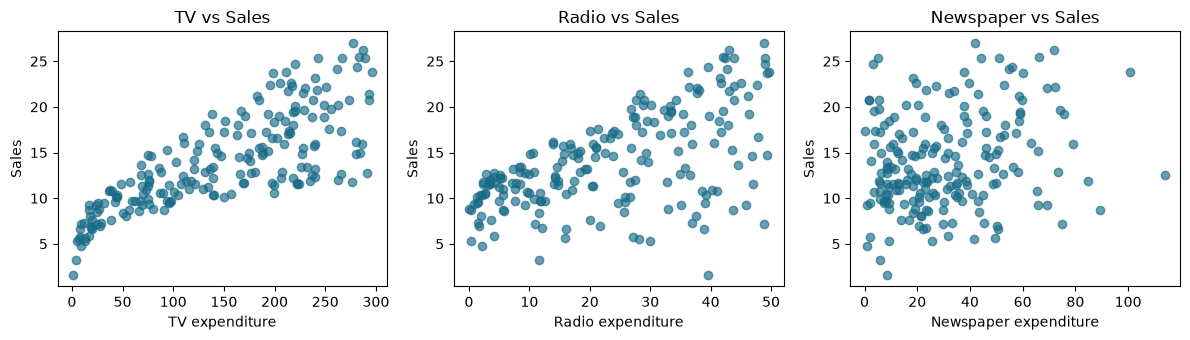

In [3]:
print(df.corr().round(3))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, feature in zip(axes, ["TV", "Radio", "Newspaper"]):
    ax.scatter(df[feature], df["Sales"], alpha=0.65, color="#176b87")
    ax.set(xlabel=feature + " expenditure", ylabel="Sales", title=feature + " vs Sales")
fig.tight_layout()

## 4. Split features and target
Use 80% of the observations for training and 20% for testing. A fixed random seed makes the split reproducible; the test data is held out during fitting.

In [4]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 160
Testing observations: 40


## 5. Train the model and inspect coefficients

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)
coefficients = pd.Series(model.coef_, index=X.columns, name="Coefficient")
print(coefficients.round(6))
print("Intercept:", round(model.intercept_, 6))
print(f"Sales = {model.intercept_:.4f} + {model.coef_[0]:.4f}*TV + {model.coef_[1]:.4f}*Radio + {model.coef_[2]:.4f}*Newspaper")

TV           0.044730
Radio        0.189195
Newspaper    0.002761
Name: Coefficient, dtype: float64
Intercept: 2.979067
Sales = 2.9791 + 0.0447*TV + 0.1892*Radio + 0.0028*Newspaper


## 6. Predict unseen sales and evaluate
**MSE:** average squared error; lower is better.

**RMSE:** square root of MSE, expressed in sales units.

**MAE:** average absolute prediction error, expressed in sales units.

**R²:** comparison with predicting the test-set mean; closer to 1 is better and it can be negative. It is not a classification accuracy percentage.

In [6]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({"Actual Sales": y_test, "Predicted Sales": y_pred})
print(comparison.head(10).round(3).to_string(index=False))
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nMSE: {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nTest R²: {r2:.4f}")
print(f"Training R²: {r2_score(y_train, model.predict(X_train)):.4f}")

 Actual Sales  Predicted Sales
         16.9           16.408
         22.4           20.890
         21.4           21.554
          7.3           10.609
         24.7           22.112
         12.6           13.106
         22.3           21.057
          8.4            7.461
         11.5           13.606
         14.9           15.155

MSE: 3.1741
RMSE: 1.7816
MAE: 1.4608
Test R²: 0.8994
Training R²: 0.8957


## 7. Predict sales for the planned advertising budget

In [7]:
new_budget = pd.DataFrame({"TV": [150], "Radio": [20], "Newspaper": [30]})
planned_sales = model.predict(new_budget)[0]
print(new_budget.to_string(index=False))
print(f"Predicted sales: {planned_sales:.4f} dataset sales units")

 TV  Radio  Newspaper
150     20         30
Predicted sales: 13.5552 dataset sales units


## 8. Strongest and weakest estimated effects
Compare coefficients per one-unit increase in expenditure, assuming expenditure uses comparable units across channels. This comparison does not measure causal impact or total feature importance.

In [8]:
print("Largest coefficient:", coefficients.idxmax(), round(coefficients.max(), 4))
print("Smallest coefficient:", coefficients.idxmin(), round(coefficients.min(), 4))

Largest coefficient: Radio 0.1892
Smallest coefficient: Newspaper 0.0028


## 9. Actual versus predicted sales and residuals
Points near the dashed diagonal indicate good predictions. Residuals are actual minus predicted sales; structure in residuals may suggest relationships the model misses.

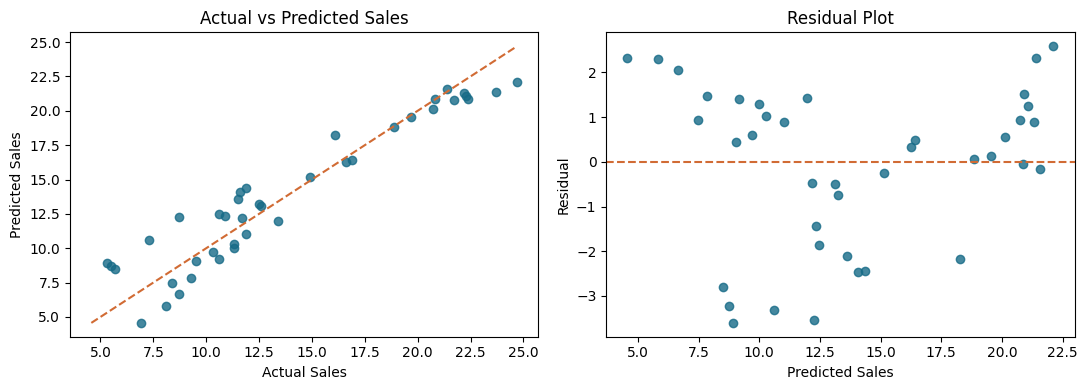

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, y_pred, color="#176b87", alpha=0.8)
lo, hi = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([lo, hi], [lo, hi], "--", color="#d16b34")
axes[0].set(xlabel="Actual Sales", ylabel="Predicted Sales", title="Actual vs Predicted Sales")
axes[1].scatter(y_pred, y_test - y_pred, color="#176b87", alpha=0.8)
axes[1].axhline(0, linestyle="--", color="#d16b34")
axes[1].set(xlabel="Predicted Sales", ylabel="Residual", title="Residual Plot")
fig.tight_layout()

## 10. Business recommendation
Radio has the largest fitted coefficient (0.1892) per unit of expenditure, while Newspaper has the smallest (0.0028). Consider testing a greater allocation to Radio while retaining TV as part of the advertising mix. Confirm decisions using campaign ROI, audience reach, and controlled experiments; these observational data alone cannot establish that reallocating expenditure causes higher sales.

## 11. Technical improvement
Explore a TV × Radio interaction and polynomial features to capture combined or nonlinear effects. Compare alternatives using cross-validation on the training data and evaluate the chosen model once on the held-out test set. Review residuals and gather more representative observations.

## Conclusion
The model was trained on 160 observations and tested on 40. Test R² is **0.8994**, MSE is **3.1741**, RMSE is **1.7816**, and MAE is **1.4608**. For the planned budget, predicted sales are **13.56 dataset sales units**. Radio has the largest per-unit estimated association and Newspaper the smallest, holding other channels fixed.